# M1 — Associative memory & the Hebbian write

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m1-associative-memory.ipynb)

**The question:** what is the single primitive everything else is built from?

First module of the foundations spine. Runs on CPU in seconds; numpy only.

Run it top to bottom, then start changing things (`d`, the number of pairs, `seed`, `beta`).

> **Prerequisite math** — *orthonormal keys* and *effective rank* (memory capacity) are covered with runnable demos in the [linear-algebra primer](../primers/linear-algebra.ipynb) §1, §3.

## Objective

After this module you should be able to:

- State what an **associative memory** is as an operator (keys → values), and why "the operator *is* the memory; fitting it *is* learning."
- Derive the **Hebbian write** $\mathcal{M}_t = \alpha_t\mathcal{M}_{t-1} + \eta_t\,\mathbf{v}_t\mathbf{k}_t^\top$ from a dot-product objective, and read/write a memory by hand.
- Explain its **two weaknesses** — interference (capacity) and state-blindness — and which later module fixes each.
- Recognize the **same recurrence** inside real code (linear attention / the HOPE fast-memory with the correction term switched off).

## Why it exists (the role it plays)

M1 is where the chain starts: the simplest memory that works, which every later module improves on. What it sets up (and later modules repair): we want a memory that stores many key→value pairs in a **fixed-size** object, recalls them, and is updated **online** (one token at a time) with no backprop-through-time. The simplest such object is one matrix you add outer products into. Everything after M1 is "the same idea, but the write is smarter.\"

## Core idea

> A memory is a matrix $\mathcal{M}$. **Read** with a matrix–vector product $\mathbf{y}=\mathcal{M}\mathbf{q}$. **Write** the pair $(\mathbf{k},\mathbf{v})$ by adding the outer product $\mathbf{v}\mathbf{k}^\top$ — because that is one gradient step on the dot-product objective $-\langle\mathcal{M}\mathbf{k},\mathbf{v}\rangle$. Adding an outer product *is* the Hebbian rule ("fire together, wire together"), and it is **identical** to the unnormalized linear-attention recurrence.

So "linear attention" and "Hebbian associative memory" are the same object under two names — the through-line we cash out in §4 and again at M3.

**Where the primitive comes from.** Hebb stated the rule in prose in *The Organization of Behavior* (1949) and wrote no formula for it. The matrix form this course runs on is the **correlation matrix memory** (store $\mathcal{M}=\sum_i\mathbf{v}_i\mathbf{k}_i^\top$, read with $\mathcal{M}\mathbf{q}$), arrived at independently in 1972 by Kohonen (*IEEE Trans. Computers*), Anderson (*Mathematical Biosciences*), and Nakano (*IEEE Trans. SMC*). The idea is Hebb's; the algebra is theirs. Fifty years on it is still the write in the recurrence, unchanged.

### Reading

- Paper grounding: [Nested Learning](https://arxiv.org/abs/2512.24695) §3.1 (Def 1, associative memory) and §5 (Hebbian / linear-attention recurrence).
- If the outer-product-as-rank-one-write feels shaky, the one fact to hold is that **a matrix product is a sum of outer products** ($AB=\sum_i\mathbf{a}_i\mathbf{b}_i^\top$ over the columns $\mathbf{a}_i$ of $A$ and the rows $\mathbf{b}_i^\top$ of $B$), so adding $\mathbf{v}\mathbf{k}^\top$ adds exactly one rank-one term to the memory.

## 1. The object: one matrix, two operations

A memory is a single matrix `M` (shape $d_v \times d_k$). Two operations:

- **Read:** `y = M @ q` — query in, value out ($\mathbf{y}=\mathcal{M}\mathbf{q}$).
- **Write** the pair `(k, v)`: `M += v k^T` — add the outer product.

Pure linear algebra, so numpy is all we need (torch arrives at M4, when we run the actual repo tensors).

> **Convention.** This notebook uses column vectors: $\mathbf{y}=\mathcal{M}\mathbf{q}$, write $\mathcal{M}\mathrel{+}=\mathbf{v}\mathbf{k}^\top$. The reference code below ([`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) → `SelfModifyingLayer`) uses the transposed row form `y = q @ M`, `M += k.T @ v`. Same object, transposed — don't let it trip you.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
d = 16  # the memory is a d x d matrix

def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)

def hebbian_write(M, k, v, alpha=1.0, eta=1.0):
    """M <- alpha*M + eta * v k^T   (add an outer product)."""
    return alpha * M + eta * np.outer(v, k)

def read(M, q):
    """y = M q."""
    return M @ q

## 2. Store a few pairs, then recall them

Write `n` random $(\mathbf{k},\mathbf{v})$ pairs into one matrix, then query each key and measure recall error. With unit-norm keys,

$$\mathcal{M}\mathbf{k}_i = \mathbf{v}_i + \sum_{j\neq i}\mathbf{v}_j\,(\mathbf{k}_j\!\cdot\!\mathbf{k}_i),$$

so the second term is **crosstalk** from every non-orthogonal key (full story in the callout at the end of this section). Watch the error grow as you store more.

In [2]:
def mean_recall_error(num_pairs, d=d, seed=0):
    r = np.random.default_rng(seed)
    M = np.zeros((d, d))
    keys = normalize(r.standard_normal((num_pairs, d)))
    vals = r.standard_normal((num_pairs, d))
    for k, v in zip(keys, vals):
        M = hebbian_write(M, k, v)
    errs = [np.linalg.norm(read(M, k) - v) / np.linalg.norm(v) for k, v in zip(keys, vals)]
    return float(np.mean(errs))

for n in (2, 8, 40):
    print(f"{n:3d} pairs -> mean relative recall error = {mean_recall_error(n):.3f}")

  2 pairs -> mean relative recall error = 0.243
  8 pairs -> mean relative recall error = 0.645
 40 pairs -> mean relative recall error = 1.639


### Play: the capacity curve

Sweep the number of stored pairs and plot recall error. Try changing `d` — capacity scales with matrix size; around $n\approx d$ the memory saturates.

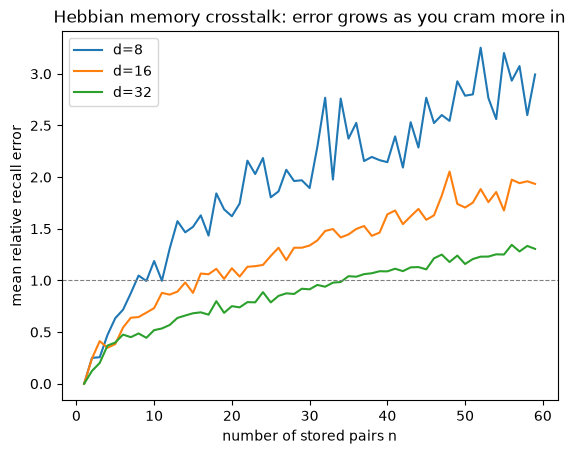

In [3]:
ns = list(range(1, 60))
for dd in (8, 16, 32):
    errs = [mean_recall_error(n, d=dd) for n in ns]
    plt.plot(ns, errs, label=f"d={dd}")
plt.axhline(1.0, ls="--", c="gray", lw=0.8)
plt.xlabel("number of stored pairs n"); plt.ylabel("mean relative recall error")
plt.title("Hebbian memory crosstalk: error grows as you cram more in")
plt.legend(); plt.show()

::: {.callout-note collapse="true"}
## Q: What is "crosstalk"?

Interference between stored associations — one stored pair leaking into the recall of another (term borrowed from telecom: signal bleeding across wires). With $\mathcal{M}=\sum_j\mathbf{v}_j\mathbf{k}_j^\top$ and unit-norm keys, querying a stored key $\mathbf{k}_i$:

$$\mathcal{M}\mathbf{k}_i = \underbrace{\mathbf{v}_i}_{\text{signal}} + \underbrace{\sum_{j\neq i}\mathbf{v}_j\,(\mathbf{k}_j\!\cdot\!\mathbf{k}_i)}_{\text{crosstalk}}.$$

Every other stored value contaminates the read, weighted by how aligned its key is with the query. It **vanishes when the other keys are orthogonal**. Since only $d$ orthogonal directions exist in $\mathbb{R}^d$, clean recall holds for up to ~$d$ keys; beyond that crosstalk is forced — the **capacity limit**. Random high-$d$ keys are near-orthogonal ($\mathbf{k}_j\!\cdot\!\mathbf{k}_i\approx\pm1/\sqrt d$), so error grows with $n$ and shrinks with $d$ — the curve above. *Test it:* set `keys = np.eye(d)[:num_pairs]` (orthonormal) in `mean_recall_error` → error ≈ 0 until `num_pairs = d`, then it breaks.
:::

## 3. State-blindness: the write ignores what `M` already knows

Write the **same** $(\mathbf{k},\mathbf{v})$ repeatedly. Hebbian has no error term, so it just keeps adding $\mathbf{v}\mathbf{k}^\top$: after $n$ writes, $\mathcal{M}\mathbf{k}=n\,\mathbf{v}$. Recall overshoots linearly and $\lVert\mathcal{M}\rVert$ blows up — the exact weakness the **delta rule (M4)** fixes.

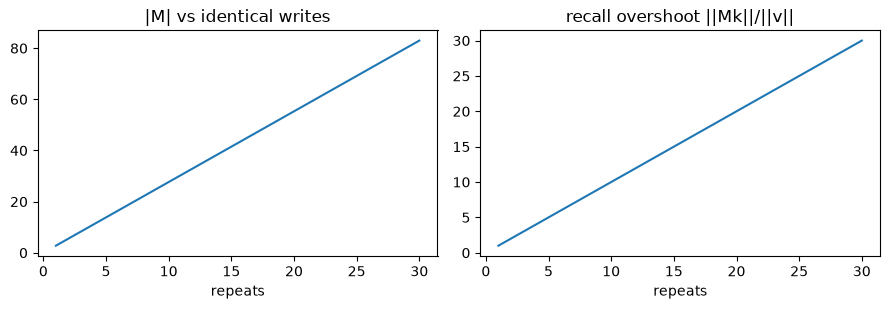

After n identical writes, Mk = n*v exactly. Hebbian never says 'I already know this'.


In [4]:
k = normalize(rng.standard_normal(d))
v = rng.standard_normal(d)
norms, overshoots = [], []
reps = range(1, 31)
for n in reps:
    M = np.zeros((d, d))
    for _ in range(n):
        M = hebbian_write(M, k, v)
    norms.append(np.linalg.norm(M))
    overshoots.append(np.linalg.norm(read(M, k)) / np.linalg.norm(v))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(list(reps), norms);      ax[0].set_title("|M| vs identical writes"); ax[0].set_xlabel("repeats")
ax[1].plot(list(reps), overshoots); ax[1].set_title("recall overshoot ||Mk||/||v||"); ax[1].set_xlabel("repeats")
plt.tight_layout(); plt.show()
print("After n identical writes, Mk = n*v exactly. Hebbian never says 'I already know this'.")

## 4. The hook to M4: delete one term to go from Hebbian to delta

HOPE's real fast memory writes the **prediction error** instead of the raw value:

```
pred  = M k            # what M already recalls for k
error = v - pred       # <-- the delta correction
M     = alpha*M + beta * outer(error, k)
```

Set `pred = 0` (don't subtract what you know) and you are back to Hebbian. Run the cell: with the error term, the **second write is ~0** and $\lVert\mathcal{M}\rVert$ stays bounded — compare to section 3. That single term `- pred` is the entire distance from M1 to M4. Play with `beta`.

In [5]:
def delta_write(M, k, v, alpha=1.0, beta=1.0):
    pred = read(M, k)             # M k  (what M already recalls for k)
    error = v - pred              # the correction Hebbian lacks
    return alpha * M + beta * np.outer(error, k)

k = normalize(rng.standard_normal(d))
v = rng.standard_normal(d)
print("repeat |  Hebbian |M|  |  delta |M|  |  delta recall err")
Mh = np.zeros((d, d)); Md = np.zeros((d, d))
for n in range(1, 11):
    Mh = hebbian_write(Mh, k, v)
    Md = delta_write(Md, k, v, beta=0.8)
    err = np.linalg.norm(read(Md, k) - v) / np.linalg.norm(v)
    print(f"  {n:2d}   |   {np.linalg.norm(Mh):7.2f}  |  {np.linalg.norm(Md):7.2f}   |   {err:.4f}")

repeat |  Hebbian |M|  |  delta |M|  |  delta recall err
   1   |      4.02  |     3.21   |   0.2000
   2   |      8.04  |     3.86   |   0.0400
   3   |     12.06  |     3.99   |   0.0080
   4   |     16.07  |     4.01   |   0.0016
   5   |     20.09  |     4.02   |   0.0003
   6   |     24.11  |     4.02   |   0.0001
   7   |     28.13  |     4.02   |   0.0000
   8   |     32.15  |     4.02   |   0.0000
   9   |     36.17  |     4.02   |   0.0000
  10   |     40.19  |     4.02   |   0.0000


::: {.callout-note collapse="true"}
## Q: What makes something "linear attention"? Is it the forget/retain gate?

No — forget/retain ($\alpha$) is a separate, optional dial; pure linear attention has $\alpha=1$ (no gate). What makes it *linear* is using the **raw dot product** $\mathbf{q}\cdot\mathbf{k}$ (or $\phi(\mathbf{q})\cdot\phi(\mathbf{k})$) as the similarity instead of softmax's nonlinear $\exp(\mathbf{q}\cdot\mathbf{k})$. Because the dot product is linear in $\mathbf{q}$, the attention sum collapses into a matrix:

$$\text{out}_t = \sum_i (\mathbf{q}_t\!\cdot\!\mathbf{k}_i)\,\mathbf{v}_i = \Big(\sum_i\mathbf{v}_i\mathbf{k}_i^\top\Big)\mathbf{q}_t = \mathcal{M}_t\,\mathbf{q}_t,\qquad \mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top.$$

So the Hebbian write **is** the linear-attention state update and the read $\mathcal{M}_t\mathbf{q}_t$ **is** the attention output ([Katharopoulos et al. 2020, "Transformers are RNNs"](https://arxiv.org/abs/2006.16236)). Softmax's $\exp$ doesn't factor, so it can't collapse — you keep every token (KV cache, $O(N^2)$).

This is also why **softmax attention is *non-parametric*** (it keeps all the raw data — every key/value — like a kNN) while **linear attention is *parametric*** (it compresses history into fixed parameters $\mathcal{M}$), paying with the Q2 crosstalk.

**Three independent dials** the paper turns: *similarity / objective* (dot-product → Hebbian, $L_2$ → delta), *gate* $\alpha$ (none / constant / learned → linear-attn / RetNet / gated), *optimizer* (one step vs many). "Linear attention" = the similarity choice; forget/retain = the gate choice. Linear attention gets its full treatment at M3; the three dials get theirs at M7.
:::

## 5. Backpropagation is an associative-memory write too

> **Prerequisite math** — *the chain rule* and *the matrix view* ($\partial\mathcal{L}/\partial W=\boldsymbol{\delta}\hat{\mathbf{x}}^\top$, the formula this section turns into a memory write) are built from scratch, with runnable demos, in the [backpropagation primer](../primers/backpropagation.ipynb) §3, §5.

The outer-product write isn't only how a *sequence memory* learns — it's how **every weight matrix learns by gradient descent**. Take one linear layer $\mathbf{y}=W\mathbf{x}$ and any loss $\mathcal{L}(\mathbf{y})$. The gradient w.r.t. $W$ is an **outer product**, the same forced shape as the Hebbian write (callout below):

$$\frac{\partial\mathcal{L}}{\partial W}=\underbrace{\frac{\partial\mathcal{L}}{\partial\mathbf{y}}}_{\boldsymbol{\delta}\ =\ \text{output surprise}}\,\mathbf{x}^\top,\qquad\text{so one SGD step}\quad W\leftarrow W-\eta\,\boldsymbol{\delta}\mathbf{x}^\top = W+(-\eta\boldsymbol{\delta})\,\mathbf{x}^\top.$$

That is **exactly the Hebbian write** $W\mathrel{+}=\mathbf{v}\mathbf{k}^\top$ with **key $=\mathbf{x}$** (the layer's input) and **value $=-\eta\boldsymbol{\delta}$** (the negative error). So $W$ is an associative memory, and training writes the association "*input $\mathbf{x}\to$ the direction that reduces its error*." The NL paper states it directly (§3.1, Eq. 8), naming $\boldsymbol{\delta}=\nabla_{\mathbf{y}}\mathcal{L}$ the **Local Surprise Signal**:

$$W_{t+1}=W_t-\eta_{t+1}\,\nabla_W\mathcal{L}(W_t;\mathbf{x}_{t+1})=W_t-\eta_{t+1}\,\big(\nabla_{\mathbf{y}}\mathcal{L}\big)\otimes\mathbf{x}_{t+1},$$

> *"backpropagation can be viewed as an associative memory that maps each data sample to the error of its corresponding prediction."*

**Every layer, not just one.** In a deep net $\partial\mathcal{L}/\partial W_\ell=\boldsymbol{\delta}_\ell\,\mathbf{x}_{\ell-1}^\top$, where $\mathbf{x}_{\ell-1}$ is *that layer's input* (the key) and $\boldsymbol{\delta}_\ell$ is the *backpropagated surprise* at its output (the value). Backprop's whole job is to produce the per-layer surprises $\boldsymbol{\delta}_\ell$; the **write** into each weight matrix is the same rank-one outer product you've used all module.

Unlike sections 1–4, where *we* handed in $\mathbf{v}$, here the value $\boldsymbol{\delta}$ is **self-generated**: it depends on the current $W$, the downstream layers, and the target, so the memory computes the very value it stores. That self-referential twist is what makes backprop *more* than vanilla Hebbian (the NL paper is careful that "backprop $\ne$ pure linear attention" for exactly this reason), and it is the thread [**M6**](m6-optimizers-as-memory.ipynb) picks up — where the *optimizer itself* (momentum, Adam) turns out to be yet another associative memory, this time compressing the **gradient** stream.

::: {.callout-note collapse="true"}
## Q: Is the gradient an outer product because $-\langle\mathcal{M}\mathbf{k},\mathbf{v}\rangle$ is a scalar $(\mathcal{M}\mathbf{k})\cdot\mathbf{v}$, and its gradient w.r.t. $\mathcal{M}$ is $\mathbf{v}\mathbf{k}^\top$?

Yes — right idea, with one shape correction: it is $\mathbf{v}\mathbf{k}^\top$ (outer product, $d_v\times d_k$), **not** $\mathbf{v}^\top\mathbf{k}$ (a scalar). A gradient w.r.t. a matrix must have the same shape as the matrix. In indices:

$$\langle\mathcal{M}\mathbf{k},\mathbf{v}\rangle = \mathbf{v}^\top\mathcal{M}\mathbf{k} = \sum_{i,j} v_i\,\mathcal{M}_{ij}\,k_j \;\Rightarrow\; \frac{\partial}{\partial\mathcal{M}_{ij}} = v_i k_j \;\Rightarrow\; \nabla_{\mathcal{M}}\langle\mathcal{M}\mathbf{k},\mathbf{v}\rangle = \mathbf{v}\mathbf{k}^\top.$$

Shape check: $\mathbf{v}\,(d_v\times1)\cdot\mathbf{k}^\top(1\times d_k)=d_v\times d_k$ = shape of $\mathcal{M}$ ✓; $\mathbf{v}^\top\mathbf{k}$ is a scalar ✗. So $\mathcal{M}\mathrel{+}=\mathbf{v}\mathbf{k}^\top$ is exactly one gradient-ascent step on the alignment — the outer-product shape is *forced*. (This "gradient w.r.t. a matrix is an outer product" move recurs everywhere: backprop's $\partial\mathcal{L}/\partial W=\boldsymbol{\delta}\,\mathbf{x}^\top$, momentum, the delta rule.)
:::

In [6]:
# A single linear layer y = W x learns by gradient descent -- and the gradient is an OUTER PRODUCT.
r = np.random.default_rng(1)
d_in, d_out = 6, 4
W = r.standard_normal((d_out, d_in))
x = normalize(r.standard_normal(d_in))      # the layer's INPUT  -> the key
target = r.standard_normal(d_out)

def layer_loss(W):                           # squared error on y = W x
    return 0.5 * np.sum((W @ x - target)**2)

delta = W @ x - target                       # output surprise  delta = dL/dy  -> the value
grad_outer = np.outer(delta, x)              # claim:  dL/dW = delta x^T

# check the claim numerically (central finite differences)
grad_fd = np.zeros_like(W); eps = 1e-5
for i in range(d_out):
    for j in range(d_in):
        Wp = W.copy(); Wp[i, j] += eps
        Wm = W.copy(); Wm[i, j] -= eps
        grad_fd[i, j] = (layer_loss(Wp) - layer_loss(Wm)) / (2 * eps)
print("dL/dW == outer(delta, x) ?", np.allclose(grad_outer, grad_fd, atol=1e-6))

# ...so one SGD step is exactly M1's Hebbian WRITE, with key = x and value = -lr * delta
lr = 0.1
W_sgd   = W - lr * grad_outer
W_write = hebbian_write(W, k=x, v=-lr * delta)     # the very function from section 1
print("SGD step == hebbian_write(W, key=x, value=-lr*delta) ?", np.allclose(W_sgd, W_write))
print("=> W is an associative memory; training writes the association  (input x  ->  -error).")

dL/dW == outer(delta, x) ? True
SGD step == hebbian_write(W, key=x, value=-lr*delta) ? True
=> W is an associative memory; training writes the association  (input x  ->  -error).


In [7]:
# Every weight matrix in a deep net is its own associative memory: key = layer input, value = backprop'd surprise.
r = np.random.default_rng(2)
W1 = r.standard_normal((5, 6)); W2 = r.standard_normal((4, 5))
x  = normalize(r.standard_normal(6)); target = r.standard_normal(4)

def forward(W1, W2):
    z = W1 @ x; h = np.maximum(z, 0); y = W2 @ h    # 2-layer MLP, ReLU
    return z, h, y
def net_loss(W1, W2):
    return 0.5 * np.sum((forward(W1, W2)[2] - target)**2)

z, h, y = forward(W1, W2)
delta2 = y - target                 # surprise at layer-2 output;  layer-2's input is h
delta1 = (W2.T @ delta2) * (z > 0)  # surprise backpropagated to layer-1 output; layer-1's input is x
g2, g1 = np.outer(delta2, h), np.outer(delta1, x)   # claim:  dL/dW_l = delta_l (input_l)^T

def fd(W, slot):                    # finite-difference gradient for whichever weight matrix
    g = np.zeros_like(W); eps = 1e-5
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Wp = W.copy(); Wp[i, j] += eps; Wm = W.copy(); Wm[i, j] -= eps
            g[i, j] = ((net_loss(W1, Wp) - net_loss(W1, Wm)) if slot == 2
                       else (net_loss(Wp, W2) - net_loss(Wm, W2))) / (2 * eps)
    return g

print("dL/dW2 == outer(delta2, h) ?", np.allclose(g2, fd(W2, 2), atol=1e-6))
print("dL/dW1 == outer(delta1, x) ?", np.allclose(g1, fd(W1, 1), atol=1e-6))
print("=> each W_l is a memory keyed by its input, valued by its local surprise; backprop just supplies the surprises.")

dL/dW2 == outer(delta2, h) ? True
dL/dW1 == outer(delta1, x) ? True
=> each W_l is a memory keyed by its input, valued by its local surprise; backprop just supplies the surprises.


## Code walkthrough — the same recurrence in real model code

The Nested Learning paper has no official code release. Two community reproductions stand in throughout this course: [obekt/HOPE-nested-learning](https://github.com/obekt/HOPE-nested-learning), mechanism-faithful and file-per-concept, and [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning), small and laptop-runnable.

Neither ships a *bare* Hebbian layer, because HOPE's fast memory is the *delta-rule* upgrade (M4). That's the best way to see M1: **the Hebbian write is the delta write with the error-correction term deleted.**

[`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) → `class SelfModifyingLayer` (`:70`). Its docstring states the recurrence verbatim:

$$\mathcal{M}_t = \alpha_t\,\mathcal{M}_{t-1} + \beta_t\,\mathbf{k}_t^\top(\mathbf{v}_t - \mathbf{k}_t\mathcal{M}_{t-1}),$$

and the inner loop (~`:120`) is literally:

```python
read_out = q_t @ memory            # y = q M   (read)
pred     = k_t @ memory            # what M already recalls for k
error    = v_t - pred              # the delta correction
update   = beta * (k_t.T @ error)  # write the ERROR as an outer product
new_memory = alpha * memory + update
```

Mentally set `pred = 0` and `alpha = beta = 1` → `new_memory = memory + k_t.T @ v_t`, the **Hebbian write**. Two conventions to keep straight:

| | read | write |
|---|---|---|
| This course / the papers (columns) | $\mathbf{y}=\mathcal{M}\mathbf{q}$ | $\mathcal{M}\mathrel{+}=\mathbf{v}\mathbf{k}^\top$ |
| `SelfModifyingLayer` (rows) | `y = q @ M` | `M += k.T @ v` |

Same matrix, transposed. It also **normalizes keys** (`F.normalize(k)`) so the delta step is well-conditioned — matters for delta (M4), harmless for Hebbian. The same repeated-write contrast lives in [`test_nested.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/test_nested.py) → `test_delta_rule` (`:60`).

## Exit check

You're ready for M2 when you can:

1. Explain why adding $\mathbf{v}\mathbf{k}^\top$ is the gradient of the dot-product objective — including why the shape is forced (§5's callout).
2. Say where the crosstalk in $\mathcal{M}\mathbf{k}$ comes from and when it vanishes (§2's callout).
3. Show why $\mathcal{M}\mathrel{+}=\mathbf{v}\mathbf{k}^\top$ *is* linear attention, and what softmax / normalization changes (§4's callout).
4. Explain why one SGD step on a linear layer is an outer-product (Hebbian) write — what plays the role of *key*, what plays the role of *value*, and why that value is *self-generated* (§5).

**Next → M2, Fast Weight Programmers.** So far $\mathbf{k},\mathbf{v},\mathbf{q}$ have been *given*. M2 asks **who produces them** — and "a slow network writes the fast network's memory" is the seed of the whole nested / levels idea.